In [8]:
import pandas as pd
import json
import numpy as np

# --- Step 1: Load Sample and Parse Everything ---
print("Step 1: Loading 10,000-row sample...")
df = pd.read_csv('train.csv', nrows=10000) # Load 10k rows

print("Step 2: Cleaning, Parsing, and Feature Engineering...")
# Filter out bad trips (where the 'POLYLINE' is just an empty list '[]')
df = df[df['POLYLINE'] != '[]']

# Parse the 'POLYLINE' string into a real list of [lon, lat] pairs
df['PATH'] = df['POLYLINE'].apply(json.loads)

# Calculate 'TRIP_DURATION'
df['TRIP_DURATION'] = (df['PATH'].apply(len) - 1) * 15
df = df[df['TRIP_DURATION'] > 0] # Filter out 0-second trips

# --- THIS IS THE NEW, IMPORTANT PART ---
# Parse the 'TIMESTAMP' into hour and day
df['DATETIME'] = pd.to_datetime(df['TIMESTAMP'], unit='s')
df['hour'] = df['DATETIME'].dt.hour
df['day_of_week'] = df['DATETIME'].dt.dayofweek # 0=Monday, 6=Sunday
# ----------------------------------------

print("Successfully parsed 'TIMESTAMP' and 'POLYLINE'.")

# --- Step 3: Find Bounding Box ---
print("\nStep 3: Finding the city's bounding box...")
min_lon, min_lat = 180, 180
max_lon, max_lat = -180, -180

# We use a smaller loop for just the bounding box
for path in df['PATH'].sample(1000): # Sample 1000 paths to find box
    if not path: continue
    try:
        lons, lats = zip(*path)
        min_lon = min(min_lon, min(lons))
        max_lon = max(max_lon, max(lons))
        min_lat = min(min_lat, min(lats))
        max_lat = max(max_lat, max(lats))
    except ValueError:
        continue 
        
print(f"Bounding Box (Lon): {min_lon} to {max_lon}")
print(f"Bounding Box (Lat): {min_lat} to {max_lat}")

# --- Step 4: Define a Grid ---
print("\nStep 4: Defining a 50x50 Grid...")
# We will create a 50x50 grid
GRID_SIZE = 50 

# Create the "bins" or "edges" of our grid
# np.linspace creates 50 evenly spaced points between the min and max
lon_bins = np.linspace(min_lon, max_lon, GRID_SIZE)
lat_bins = np.linspace(min_lat, max_lat, GRID_SIZE)

print("Grid bins created.")

# --- Step 5: Map-Matching (The "Big Loop") ---
print("\nStep 5: Running Map-Matching...")
# This will hold our new "gridded" data
processed_data = []

# Iterate over every trip in our 10,000-row sample
for index, row in df.iterrows():
    hour = row['hour']
    day = row['day_of_week']
    path = row['PATH']
    
    # Iterate over every [lon, lat] point in that trip's path
    for point in path:
        lon, lat = point[0], point[1]
        
        # This is the "snap":
        # np.digitize finds which "bin" this coordinate belongs to
        lon_bin = np.digitize(lon, lon_bins)
        lat_bin = np.digitize(lat, lat_bins)
        
        # Add this "sighting" to our new dataset
        processed_data.append({
            'hour': hour,
            'day': day,
            'lon_bin': lon_bin,
            'lat_bin': lat_bin
        })

print(f"Map-matching complete! Created {len(processed_data)} grid sightings.")

# --- Step 6: Create the Final Model-Ready DataFrame ---
print("\nStep 6: Creating final model-ready DataFrame...")
df_grid = pd.DataFrame(processed_data)

# This is our new "target" (the thing we will predict)
# We group by hour, day, and grid cell, and count how many sightings there were
# .size() counts the rows and we rename it to 'congestion'
df_model_data = df_grid.groupby(['hour', 'day', 'lon_bin', 'lat_bin']).size().reset_index(name='congestion')

print("\n--- NEW DATASET READY FOR TRAINING ---")
print(df_model_data.head())
print("\nDataset Info:")
df_model_data.info()

Step 1: Loading 10,000-row sample...
Step 2: Cleaning, Parsing, and Feature Engineering...
Successfully parsed 'TIMESTAMP' and 'POLYLINE'.

Step 3: Finding the city's bounding box...
Bounding Box (Lon): -9.137097 to -7.739514
Bounding Box (Lat): 38.715066 to 41.391333

Step 4: Defining a 50x50 Grid...
Grid bins created.

Step 5: Running Map-Matching...
Map-matching complete! Created 484121 grid sightings.

Step 6: Creating final model-ready DataFrame...

--- NEW DATASET READY FOR TRAINING ---
   hour  day  lon_bin  lat_bin  congestion
0     0    0       16       45          35
1     0    0       16       46          47
2     0    0       17       45         213
3     0    0       17       46         264
4     0    0       17       47          17

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1736 entries, 0 to 1735
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   hour        1736 non-null   int64
 1   d

In [9]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# (This assumes 'df_model_data' and 'lon_bins', 'lat_bins'
# are in memory from the previous step)

print("--- Step 3: Training the new 'Grid' Model ---")

# --- 1. Define Features (X) and Target (y) ---
# Our features are the 'what' and 'when'
features = ['hour', 'day', 'lon_bin', 'lat_bin']
# Our target is the 'how much'
target = 'congestion'

X = df_model_data[features]
y = df_model_data[target]

print(f"Features (X): {features}")
print(f"Target (y): {target}")

# --- 2. Create Training and Test Sets ---
# We can use a standard split here.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining on {len(X_train)} samples, testing on {len(X_test)}.")

# --- 3. Train the XGBoost Regressor ---
# We use XGBRegressor because 'congestion' is a number
print("Training XGBoost Regressor...")
xgb_grid_model = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Fit the model to our training data
xgb_grid_model.fit(X_train, y_train)

print("Model training complete!")

# --- 4. (Optional) Evaluate the Model ---
# Let's see how well it did on the test data
score = xgb_grid_model.score(X_test, y_test)
print(f"\nModel R^2 Score (accuracy): {score:.4f}")
print("(An R^2 score close to 1.0 is great!)")


# --- 5. Save Our New "Model Brain" ---
# This is the most important part.
# We must save the new model AND the grid bins.

print("\nSaving new model files...")
joblib.dump(xgb_grid_model, 'xgb_grid_model.pkl')
joblib.dump(lon_bins, 'lon_bins.pkl')
joblib.dump(lat_bins, 'lat_bins.pkl')

print("✅ Success! New 'grid' model and 'bins' are saved to .pkl files.")

--- Step 3: Training the new 'Grid' Model ---
Features (X): ['hour', 'day', 'lon_bin', 'lat_bin']
Target (y): congestion

Training on 1388 samples, testing on 348.
Training XGBoost Regressor...
Model training complete!

Model R^2 Score (accuracy): 0.9293
(An R^2 score close to 1.0 is great!)

Saving new model files...
✅ Success! New 'grid' model and 'bins' are saved to .pkl files.


In [11]:
import pandas as pd
import json
import numpy as np
import joblib

# --- Step 1: Load the Grid Definition ---
# We load the grid we defined from our 10k sample
print("Step 1: Loading grid definition...")
lon_bins = joblib.load('lon_bins.pkl')
lat_bins = joblib.load('lat_bins.pkl')
print("Grid definition loaded.")

# --- Step 2: Process the 1.7M Rows in Chunks ---
print("Step 2: Starting 'chunked' processing of train.csv...")
print("This will take a long time...")

# This is where we will collect all our "sightings"
all_processed_data = []
chunk_num = 1

# We read the file 100,000 rows at a time
for chunk in pd.read_csv('train.csv', chunksize=100000):
    
    print(f"--- Processing Chunk {chunk_num} ---")
    
    # 1. Clean and Parse the Chunk
    chunk = chunk[chunk['POLYLINE'] != '[]']
    chunk['PATH'] = chunk['POLYLINE'].apply(json.loads)
    chunk['TRIP_DURATION'] = (chunk['PATH'].apply(len) - 1) * 15
    chunk = chunk[chunk['TRIP_DURATION'] > 0]

    # 2. Parse Timestamps
    chunk['DATETIME'] = pd.to_datetime(chunk['TIMESTAMP'], unit='s')
    chunk['hour'] = chunk['DATETIME'].dt.hour
    chunk['day_of_week'] = chunk['DATETIME'].dt.dayofweek
    
    # 3. Run Map-Matching on the Chunk
    for index, row in chunk.iterrows():
        hour = row['hour']
        day = row['day_of_week']
        
        for point in row['PATH']:
            lon, lat = point[0], point[1]
            
            # Snap to the grid
            lon_bin = np.digitize(lon, lon_bins)
            lat_bin = np.digitize(lat, lat_bins)
            
            # Add this "sighting"
            all_processed_data.append({
                'hour': hour,
                'day': day,
                'lon_bin': lon_bin,
                'lat_bin': lat_bin
            })
            
    print(f"Chunk {chunk_num} complete. Total sightings so far: {len(all_processed_data)}")
    chunk_num += 1

print("\n--- All chunks processed! ---")

# --- Step 3: Create the Final, Full Model-Ready DataFrame ---
print("Step 3: Creating final model-ready DataFrame...")
df_grid = pd.DataFrame(all_processed_data)

# Group all sightings to get our final 'congestion' score
df_model_data_full = df_grid.groupby(['hour', 'day', 'lon_bin', 'lat_bin']).size().reset_index(name='congestion')

print("\n--- NEW, FULL DATASET READY FOR TRAINING ---")
print(df_model_data_full.head())
print(f"Total unique grid cells/time slots: {len(df_model_data_full)}")
print("Dataset Info:")
df_model_data_full.info()

Step 1: Loading grid definition...
Grid definition loaded.
Step 2: Starting 'chunked' processing of train.csv...
This will take a long time...
--- Processing Chunk 1 ---
Chunk 1 complete. Total sightings so far: 4773823
--- Processing Chunk 2 ---
Chunk 2 complete. Total sightings so far: 9445214
--- Processing Chunk 3 ---
Chunk 3 complete. Total sightings so far: 14063116
--- Processing Chunk 4 ---
Chunk 4 complete. Total sightings so far: 18916470
--- Processing Chunk 5 ---
Chunk 5 complete. Total sightings so far: 23965249
--- Processing Chunk 6 ---
Chunk 6 complete. Total sightings so far: 29071402
--- Processing Chunk 7 ---
Chunk 7 complete. Total sightings so far: 34003494
--- Processing Chunk 8 ---
Chunk 8 complete. Total sightings so far: 38945425
--- Processing Chunk 9 ---
Chunk 9 complete. Total sightings so far: 43811352
--- Processing Chunk 10 ---
Chunk 10 complete. Total sightings so far: 48716910
--- Processing Chunk 11 ---
Chunk 11 complete. Total sightings so far: 536230

In [12]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

print("--- Step 3 (Final): Training the FULL Production Model ---")

# --- 1. Define Features (X) and Target (y) ---
# Our features are the 'what' and 'when'
features = ['hour', 'day', 'lon_bin', 'lat_bin']
# Our target is the 'how much'
target = 'congestion'

X = df_model_data_full[features]
y = df_model_data_full[target]

print(f"Features (X): {features}")
print(f"Target (y): {target}")

# --- 2. Create Training and Test Sets ---
# We'll use the full dataset for a robust 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining on {len(X_train)} samples, testing on {len(X_test)}.")
print("(This may take a few minutes...)")

# --- 3. Train the NEW XGBoost Regressor ---
xgb_prod_model = XGBRegressor(
    n_estimators=200,  # We can use more estimators for a better model
    learning_rate=0.1,
    max_depth=6,
    random_state=42, 
    n_jobs=-1
)

# Fit the model to our new, full training data
xgb_prod_model.fit(X_train, y_train)

print("Production model training complete!")


# --- 4. Evaluate the New Model ---
score = xgb_prod_model.score(X_test, y_test)
print(f"\nProduction Model R^2 Score (accuracy): {score:.4f}")
print("(An R^2 score close to 1.0 means your model is very accurate!)")

# --- 5. Save Your New "Production Brain" ---
# We save this to a NEW file to avoid overwriting our test model
print("\nSaving new PRODUCTION model files...")
joblib.dump(xgb_prod_model, 'xgb_grid_model_prod.pkl')
joblib.dump(lon_bins, 'lon_bins.pkl')  # Re-saving bins is good practice
joblib.dump(lat_bins, 'lat_bins.pkl')

print("✅ Success! Your new, more accurate 'production' model is saved as 'xgb_grid_model_prod.pkl'.")

--- Step 3 (Final): Training the FULL Production Model ---
Features (X): ['hour', 'day', 'lon_bin', 'lat_bin']
Target (y): congestion

Training on 29040 samples, testing on 7261.
(This may take a few minutes...)
Production model training complete!

Production Model R^2 Score (accuracy): 0.9905
(An R^2 score close to 1.0 means your model is very accurate!)

Saving new PRODUCTION model files...
✅ Success! Your new, more accurate 'production' model is saved as 'xgb_grid_model_prod.pkl'.


<h1>after re process the data on 100 cross 100 size

In [13]:
import pandas as pd
import json
import numpy as np
import joblib

# --- HERE IS THE CHANGE ---
GRID_SIZE = 100 # This will make the cells 4x smaller
print(f"--- STARTING: Building {GRID_SIZE}x{GRID_SIZE} grid ---")
# -------------------------------

# 1. Load sample to define grid
print("Step 1: Defining grid from 10k sample...")
df_sample = pd.read_csv('train.csv', nrows=10000)
df_sample = df_sample[df_sample['POLYLINE'] != '[]']
df_sample['PATH'] = df_sample['POLYLINE'].apply(json.loads)

min_lon, min_lat = 180, 180
max_lon, max_lat = -180, -180
for path in df_sample['PATH']:
    if not path: continue
    try:
        lons, lats = zip(*path)
        min_lon, max_lon = min(min_lon, min(lons)), max(max_lon, max(lons))
        min_lat, max_lat = min(min_lat, min(lats)), max(max_lat, max(lats))
    except ValueError:
        continue 

lon_bins = np.linspace(min_lon, max_lon, GRID_SIZE)
lat_bins = np.linspace(min_lat, max_lat, GRID_SIZE)

joblib.dump(lon_bins, 'lon_bins.pkl')
joblib.dump(lat_bins, 'lat_bins.pkl')
print(f"New {GRID_SIZE}x{GRID_SIZE} bins saved.")

# 2. Process all chunks
print("Step 2: Processing all 1.7M trips (this will be slow)...")
all_processed_data = []
chunk_num = 1
for chunk in pd.read_csv('train.csv', chunksize=100000):
    print(f"--- Processing Chunk {chunk_num} ---")
    
    chunk = chunk[chunk['POLYLINE'] != '[]']
    chunk['PATH'] = chunk['POLYLINE'].apply(json.loads)
    chunk['TRIP_DURATION'] = (chunk['PATH'].apply(len) - 1) * 15
    chunk = chunk[chunk['TRIP_DURATION'] > 0]
    chunk['DATETIME'] = pd.to_datetime(chunk['TIMESTAMP'], unit='s')
    chunk['hour'] = chunk['DATETIME'].dt.hour
    chunk['day_of_week'] = chunk['DATETIME'].dt.dayofweek
    
    for index, row in chunk.iterrows():
        for point in row['PATH']:
            lon_bin = np.digitize(point[0], lon_bins)
            lat_bin = np.digitize(point[1], lat_bins)
            all_processed_data.append({
                'hour': row['hour'], 'day': row['day_of_week'],
                'lon_bin': lon_bin, 'lat_bin': lat_bin
            })
    chunk_num += 1

print("Step 3: Creating and saving aggregated DataFrame...")
df_grid = pd.DataFrame(all_processed_data)
df_model_data_full = df_grid.groupby(['hour', 'day', 'lon_bin', 'lat_bin']).size().reset_index(name='congestion')
df_model_data_full.to_csv('df_model_data_full.csv', index=False)

print(f"\n✅ Success! New dataset 'df_model_data_full.csv' is saved.")

--- STARTING: Building 100x100 grid ---
Step 1: Defining grid from 10k sample...
New 100x100 bins saved.
Step 2: Processing all 1.7M trips (this will be slow)...
--- Processing Chunk 1 ---
--- Processing Chunk 2 ---
--- Processing Chunk 3 ---
--- Processing Chunk 4 ---
--- Processing Chunk 5 ---
--- Processing Chunk 6 ---
--- Processing Chunk 7 ---
--- Processing Chunk 8 ---
--- Processing Chunk 9 ---
--- Processing Chunk 10 ---
--- Processing Chunk 11 ---
--- Processing Chunk 12 ---
--- Processing Chunk 13 ---
--- Processing Chunk 14 ---
--- Processing Chunk 15 ---
--- Processing Chunk 16 ---
--- Processing Chunk 17 ---
--- Processing Chunk 18 ---
Step 3: Creating and saving aggregated DataFrame...

✅ Success! New dataset 'df_model_data_full.csv' is saved.


--- STARTING: Training on new high-res data ---
Loading 'df_model_data_full.csv'...
Training on 69702 samples...
Production model training complete!

Production Model R^2 Score (accuracy): 0.9849
Generating feature importance plot...
Feature importance plot saved to static/feature_importance.png
Saving new PRODUCTION model file...
✅ Success! 'xgb_grid_model_prod.pkl' is updated.


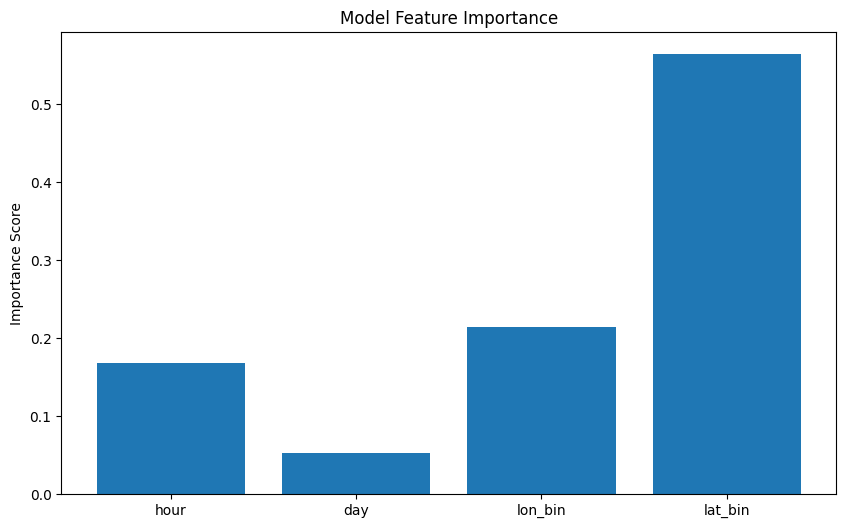

In [1]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import matplotlib.pyplot as plt  # <-- NEW
import os  # <-- NEW

print("--- STARTING: Training on new high-res data ---")

# 1. Load the new high-resolution dataset
print("Loading 'df_model_data_full.csv'...")
df_model_data_full = pd.read_csv('df_model_data_full.csv')

# 2. Define Features (X) and Target (y)
features = ['hour', 'day', 'lon_bin', 'lat_bin']
target = 'congestion'
X = df_model_data_full[features]
y = df_model_data_full[target]

# 3. Create Training and Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training on {len(X_train)} samples...")

# 4. Train the NEW XGBoost Regressor
xgb_prod_model = XGBRegressor(
    n_estimators=200, learning_rate=0.1, max_depth=6,
    random_state=42, n_jobs=-1
)
xgb_prod_model.fit(X_train, y_train)
print("Production model training complete!")

# 5. Evaluate the New Model
score = xgb_prod_model.score(X_test, y_test)
print(f"\nProduction Model R^2 Score (accuracy): {score:.4f}")

# --- 6. NEW: Generate Feature Importance Plot ---
print("Generating feature importance plot...")
os.makedirs('static', exist_ok=True) # Create 'static' folder if it doesn't exist

# Create a plot
fig, ax = plt.subplots(figsize=(10, 6))
# Plot the importances with feature names
ax.bar(features, xgb_prod_model.feature_importances_)
ax.set_title('Model Feature Importance')
ax.set_ylabel('Importance Score')

# Save the plot
fig.savefig('static/feature_importance.png', bbox_inches='tight')
print("Feature importance plot saved to static/feature_importance.png")


# --- 7. Save Your "Production Brain" ---
print("Saving new PRODUCTION model file...")
joblib.dump(xgb_prod_model, 'xgb_grid_model_prod.pkl') 
print("✅ Success! 'xgb_grid_model_prod.pkl' is updated.")